## 3.1例子

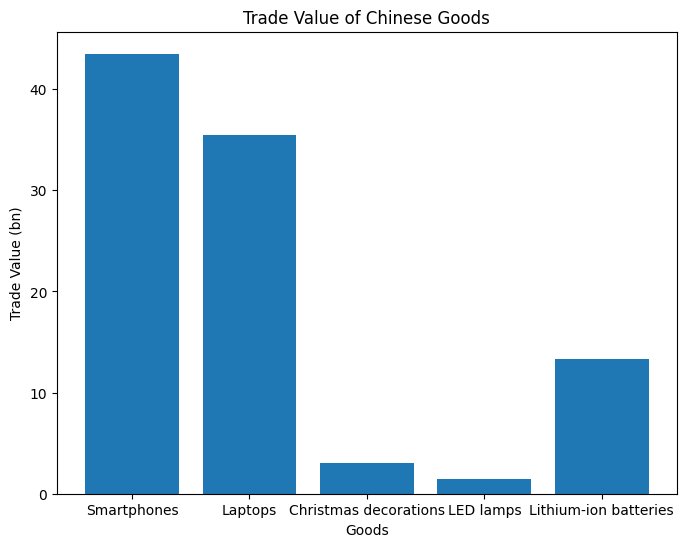

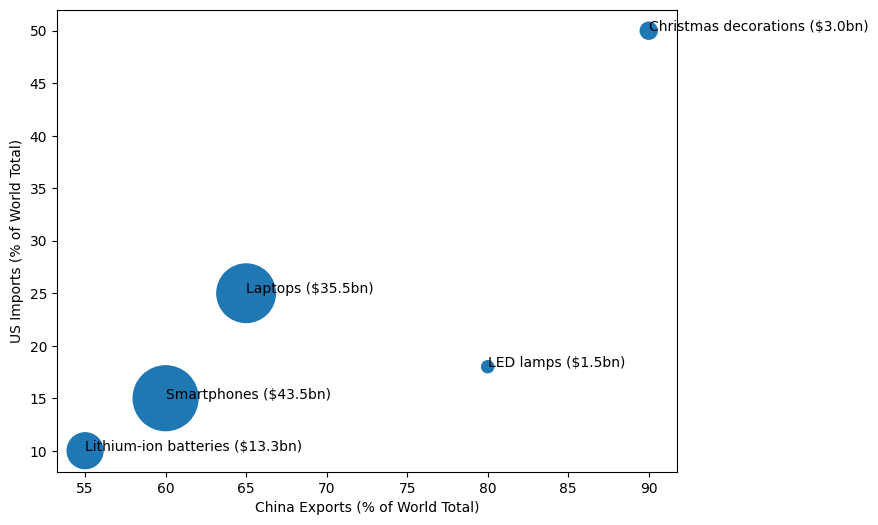

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
# 设置工作目录
work_dir = r"D:\jjdsjyrgzn_python\3shangjike"
os.chdir(work_dir)
# 导入数据
data = pd.read_excel("trade_data.xlsx")
# 数据解析：提取各列数据
x_vals = data["China_exports_in_world_%"]
y_vals = data["US_imports_in_world_%"]
values = data["Trade_value_from_China_to_US_bn"]
names = data["Name"]
# 绘制柱状图
plt.figure(figsize=(8, 6))
plt.bar(names , values)
plt.title("Trade Value of Chinese Goods")
plt.xlabel("Goods")
plt.ylabel("Trade Value (bn)")
plt.show()
# 绘制散点图
plt.figure(figsize=(8, 6))
plt.scatter(x_vals , y_vals , s=values * 50) # 气泡大小与贸易额成比例
for i in range(len(names)):
    plt.annotate(f"{names.iloc[i]} (${values.iloc[i]}bn)", (x_vals.iloc[i], y_vals.iloc[i]))
plt.xlabel("China Exports (% of World Total)")
plt.ylabel("US Imports (% of World Total)")
plt.show()

## 3.2知识点拆解
### 导入模块
os：Operating System（操作系统）的缩写。提供与操作系统交互的功能，用于管理文件和目录，比如新建文件夹、删除文件、获取当前工作路径、遍历文件夹里的所有图片等。  
pandas：源于Panel Data和Statistics。强大的数据分析库，可以处理结构化数据（如最核心功能是表格数据）  
matplotlib.pyplot：mat: 取自 MATLAB、plot、Library。绘图库，用于生成各种可视化图表
### 设置工作目录
通过 os.chdir() ，change directory的缩写，设置工作目录，确保程序能够正确定位到数据文件。

### 导入数据
使用 pandas 的 read_excel() 方法可以轻松读取 Excel 文件，并将其转换为 DataFrame数据结构。在导入数据后，可以通过以下方法查看数据的大致结构：

In [3]:
data = pd.read_excel("trade_data.xlsx") 
# 查看前5行数据
print(data.head())
# 查看列名
print(data.columns)
# 查看数据的维度，输出 (行数 , 列数)
print(data.shape)

                    Name  China_exports_in_world_%  US_imports_in_world_%  \
0            Smartphones                        60                     15   
1                Laptops                        65                     25   
2  Christmas decorations                        90                     50   
3              LED lamps                        80                     18   
4  Lithium-ion batteries                        55                     10   

   Trade_value_from_China_to_US_bn  
0                             43.5  
1                             35.5  
2                              3.0  
3                              1.5  
4                             13.3  
Index(['Name', 'China_exports_in_world_%', 'US_imports_in_world_%',
       'Trade_value_from_China_to_US_bn'],
      dtype='object')
(5, 4)


取数的其他实用参数配置，以下面这段代码为例：
```
import pandas as pd
df = pd.read_excel('某一个excel.xlsx', sheet_name=0, nrows=5, usecols="A:C")
print(df.shape)
```
- sheet_name=0：代表读取 Excel 文件里的第一张工作表（Sheet1）。
- nrows=5：代表只读取前 5 行数据（通常用来快速预览一个超大的表格）。
- usecols="A:C"：代表只读取 Excel 表格里的 A 列、B 列、C 列。

### 提取列数据并画图
在 DataFrame 中，可以通过列名提取某一列的数据，返回一个 pandas.Series 对象。提取列数据的目的是为了对某些特定信息进行单独操作，比如绘图或分析。通过提取列数据，可以让代码更加简洁、清晰，同时便于后续操作和复用。

也可以直接提取某一个数字，例如data.iloc[2, 1]是提取Pandas DataFrame 中的第 3 行第 2 列数据  

散点图中s 参数控制的是点的面积,不是半径。可以设置为数组。

柱状图的横轴可以是字符串也可以是数字类别（比如年份）。
柱状图的纵轴必须是数值。

在图表中添加标注可以使数据展示更加直观，尤其是在散点图中，可以通过标注进一步解释每个点的含义。plt.annotate() 是 matplotlib 提供的一个方法，用于在图表的指定位置添加文本信息。
#### 循环部分
for i in range(len(names)):
- 使用 for 循环遍历每个数据点。
- len(names) 表示数据点的总数（即商品的数量）。
- i 是当前循环的索引，用于访问每个商品的名称、贸易额以及对应的坐标。
#### plt.annotate() 的第一个参数
f"{names.iloc[i]} (${values.iloc[i]}bn)"
- f"" 是 Python 的格式化字符串，用于动态生成标注内容。
- names.iloc[i]：获取第 i 个商品的名称。
- values.iloc[i]：获取第 i 个商品的贸易额。
- 标注内容示例："Laptops ($50bn)"，表示商品名称和对应的贸易额。
- plt.annotate() 完全可以只添加纯文本注释。
#### plt.annotate() 的第二个参数
(x_vals.iloc[i], y_vals.iloc[i])
- 指定标注的位置，即当前点的横坐标和纵坐标。
- x_vals.iloc[i]：获取第 i 个点的横坐标（中国出口占比）。
- y_vals.iloc[i]：获取第 i 个点的纵坐标（美国进口占比）。
#### iloc 的作用
- iloc 是 Pandas 提供的方法，用于基于整数索引（行号或列号）访问数据。
- 语法：DataFrame.iloc[row_index, column_index] 或 Series.iloc[row_index]。
- 在本例中，iloc[i] 用于通过第 i 行的索引逐行提取数据：
- names.iloc[i]：提取第 i 行的商品名称。
- x_vals.iloc[i]：提取第 i 行的横坐标值（中国出口占比）。
- y_vals.iloc[i]：提取第 i 行的纵坐标值（美国进口占比）。
- values.iloc[i]：提取第 i 行的贸易额。
- 使用 iloc 的好处是可以按行号逐行访问数据，适合循环遍历和逐点标注。

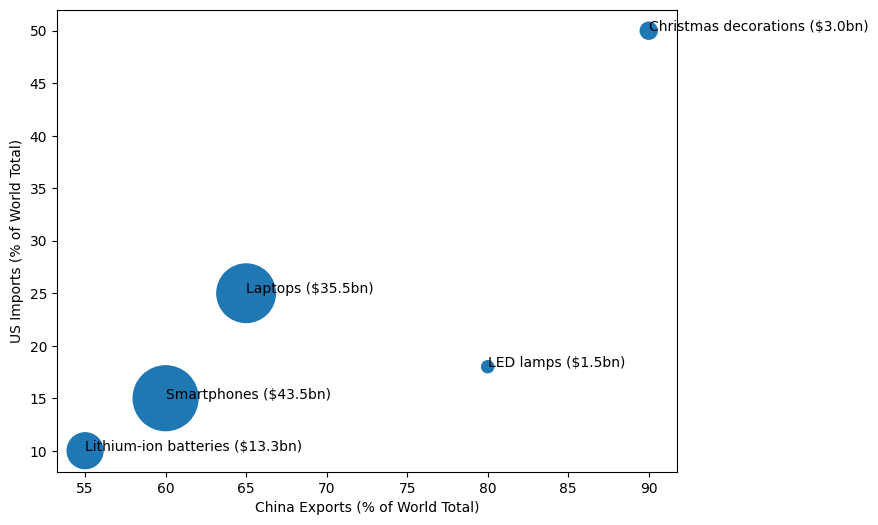

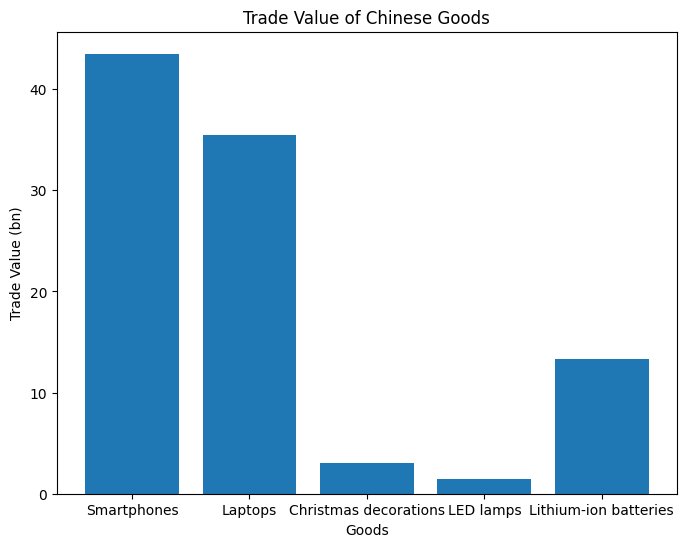

In [10]:
# 提取中国出口占比
x_vals = data["China_exports_in_world_%"]
# 提取美国进口占比
y_vals = data["US_imports_in_world_%"]
# 提取贸易额
values = data["Trade_value_from_China_to_US_bn"] 
# 提取商品名称
names = data["Name"] 
# 提取列数据后绘图
# 第一张纸：画散点图
plt.figure(figsize=(8, 6))
# 设置横纵坐标和气泡大小缩放比例
plt.scatter(x_vals , y_vals , s=values * 50) 
# 横轴标签
plt.xlabel("China Exports (% of World Total)") 
# 纵轴标签
plt.ylabel("US Imports (% of World Total)")
# 添加标注，标注商品名称和贸易额
for i in range(len(names)):
    plt.annotate(f"{names.iloc[i]} (${values.iloc[i]}bn)",
                    (x_vals.iloc[i], y_vals.iloc[i]))  
# 显示图像
plt.show() 
# 第二张纸：画柱状图
# 设置画布大小
plt.figure(figsize=(8, 6))
# 横轴为商品名称，纵轴为贸易额
plt.bar(names , values) 
 # 设置标题
plt.title("Trade Value of Chinese Goods")
# 横轴标签
plt.xlabel("Goods")
 # 纵轴标签 
plt.ylabel("Trade Value (bn)")
# 显示图像
plt.show() 

如果不提取列数据，代码会变得更加冗长和复杂。例如，在绘制图表时，每次都需要直接从 DataFrame 中访问列数据：

<BarContainer object of 5 artists>

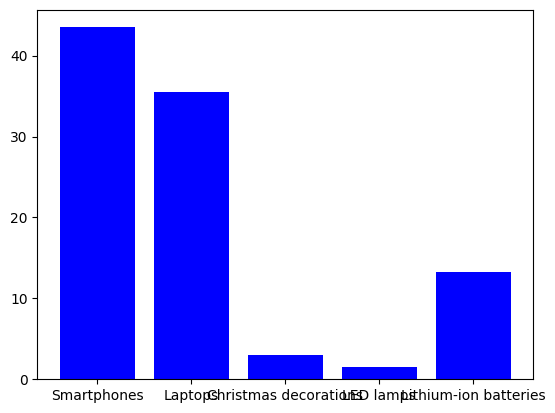

In [11]:
# 不提取列数据的做法
plt.scatter(data["China_exports_in_world_%"],
            data["US_imports_in_world_%"],
            s=data["Trade_value_from_China_to_US_bn"] * 50)
plt.bar(data["Name"], data["Trade_value_from_China_to_US_bn"], color='blue'
)

基础练习里的画图代码

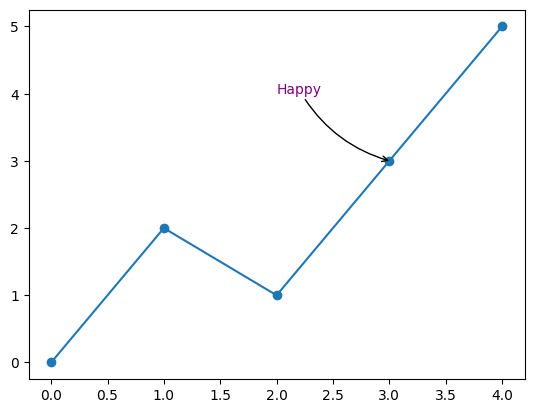

In [ ]:
x = [0, 1, 2, 3, 4]
y = [0, 2, 1, 3, 5]
plt.plot(x, y, marker='o')
plt.annotate('Happy',
            xy=(3, 3), # xy 参数指定的是被标注的数据点的位置（箭头指着的地方）
            xytext=(2, 4), 3 xytext 是文字起点的位置
            arrowprops=dict(facecolor='green', arrowstyle='->', shrinkA=0.1, shrinkB=0.1, connectionstyle='arc3 ,rad=0.2'), # shrinkA 和 shrinkB 是让箭头两端稍微缩短一点，不要死死贴着文字和数据点，让图表更美观。
            fontsize=10, color='purple')
plt.show()